<a href="https://colab.research.google.com/github/andresanchez256/Portafolio/blob/main/Proyecto_Clasificacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏦 Análisis de Riesgo Crediticio con Machine Learning

## 📌 Contexto del Negocio

Las instituciones financieras enfrentan un desafío crítico: **evaluar la probabilidad de que un solicitante de crédito no pague su préstamo**. Una decisión incorrecta puede significar:

- **Falso Positivo** (rechazar a un buen cliente): Pérdida de oportunidad de negocio
- **Falso Negativo** (aprobar a un mal cliente): Pérdida financiera directa

En este proyecto, utilizaremos el **German Credit Dataset** para construir un modelo predictivo que estime la probabilidad de impago de un cliente.

## 🎯 Objetivo del Proyecto

Desarrollar y comparar dos modelos de machine learning (Regresión Logística y Random Forest) para predecir la probabilidad de impago, optimizando el umbral de decisión según una **matriz de costos** que refleja el impacto real en el negocio.

## 📊 Dataset

- **Fuente**: UCI Machine Learning Repository
- **Registros**: 1,000 solicitudes de crédito
- **Variables**: 24 características (financieras, demográficas, historial crediticio)
- **Distribución**: 70% buenos pagadores, 30% malos pagadores

## 💰 Matriz de Costos

| | Predicho: Bueno | Predicho: Malo |
|---|---|---|
| **Real: Bueno** | Costo = 0 | Costo = 1 (oportunidad perdida) |
| **Real: Malo** | Costo = 5 (pérdida financiera) | Costo = 0 |

El costo de un **Falso Negativo** (clasificar a un mal cliente como bueno) es **5 veces mayor** que el de un Falso Positivo.

In [17]:
# ============================================
# CONFIGURACIÓN INICIAL
# ============================================

# Instalar librerías (descomentar si es necesario)
# !pip install -q pandas numpy scikit-learn matplotlib seaborn

# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix,
                             classification_report, precision_recall_curve)
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


In [28]:
# ============================================
# CARGA DE DATOS (CON NOMBRES DESCRIPTIVOS)
# ============================================

# URL del dataset
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data-numeric'

# Cargar datos
df = pd.read_csv(url, sep='\s+', header=None)

# Definir nombres descriptivos de las columnas
# Basado en la documentación del German Credit Dataset
column_names = [
    'status_account',       # Estado de cuenta corriente
    'duration_months',      # Duración del préstamo en meses
    'credit_history',       # Historial crediticio
    'purpose',              # Propósito del préstamo
    'amount',               # Monto del préstamo (DM)
    'savings_account',      # Cuenta de ahorros
    'employment_duration',  # Antigüedad laboral
    'installment_rate',     # Tasa de cuota (% de ingreso)
    'personal_status_sex',  # Estado civil y género
    'other_debtors',        # Otros deudores
    'residence_since',      # Años en residencia actual
    'property',             # Propiedad
    'age',                  # Edad en años
    'other_installment_plans', # Otros planes de cuota
    'housing',              # Situación de vivienda
    'existing_credits_count', # Número de créditos existentes
    'job',                  # Tipo de trabajo
    'people_liable',        # Número de personas a cargo
    'telephone',            # Teléfono
    'foreign_worker',       # Trabajador extranjero
    'feature_21',           # Variable adicional
    'feature_22',           # Variable adicional
    'feature_23',           # Variable adicional
    'feature_24'            # Variable adicional
]

# Asignar nombres a todas las columnas (24 features + 1 clase)
df.columns = column_names + ['class']

# Crear target: 0 = buen pagador, 1 = mal pagador
df['target'] = df['class'].apply(lambda x: 0 if x == 1 else 1)
df = df.drop('class', axis=1)

print(f"✅ Datos cargados: {df.shape[0]} registros, {df.shape[1]} columnas")
print(f"\n📋 Columnas disponibles:")
print(df.columns.tolist())
print(f"\n📊 Distribución de la variable objetivo:")
print(f"  - Buenos pagadores (0): {sum(df['target']==0)} ({sum(df['target']==0)/len(df)*100:.1f}%)")
print(f"  - Malos pagadores (1): {sum(df['target']==1)} ({sum(df['target']==1)/len(df)*100:.1f}%)")

✅ Datos cargados: 1000 registros, 25 columnas

📋 Columnas disponibles:
['status_account', 'duration_months', 'credit_history', 'purpose', 'amount', 'savings_account', 'employment_duration', 'installment_rate', 'personal_status_sex', 'other_debtors', 'residence_since', 'property', 'age', 'other_installment_plans', 'housing', 'existing_credits_count', 'job', 'people_liable', 'telephone', 'foreign_worker', 'feature_21', 'feature_22', 'feature_23', 'feature_24', 'target']

📊 Distribución de la variable objetivo:
  - Buenos pagadores (0): 700 (70.0%)
  - Malos pagadores (1): 300 (30.0%)


## 🎯 Análisis de la Variable Objetivo

### Distribución de Clases

El dataset presenta un **desbalanceo significativo**: solo el 30% de los casos son malos pagadores. Esto es realista en el mundo financiero, donde la mayoría de los clientes cumplen con sus obligaciones.

**Implicaciones para el modelado**:
- La **exactitud (accuracy)** no es una métrica apropiada (un modelo que predijera "bueno" siempre tendría 70% de accuracy)
- Usaremos **AUC-ROC** y **Recall** como métricas principales
- Ajustaremos el **umbral de decisión** según la matriz de costos

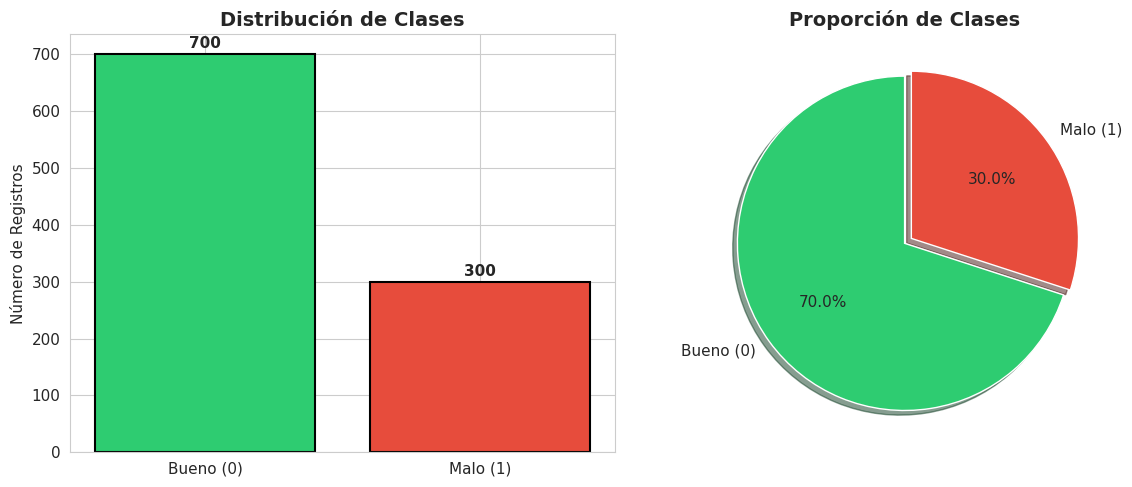


📊 Ratio de desbalanceo: 2.33:1


In [29]:
# ============================================
# VISUALIZACIÓN DE LA VARIABLE OBJETIVO
# ============================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de barras
class_counts = df['target'].value_counts()
colors = ['#2ecc71', '#e74c3c']
bars = ax1.bar(['Bueno (0)', 'Malo (1)'], class_counts, color=colors,
               edgecolor='black', linewidth=1.5)
ax1.set_title('Distribución de Clases', fontsize=14, fontweight='bold')
ax1.set_ylabel('Número de Registros')
for bar, count in zip(bars, class_counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(count), ha='center', va='bottom', fontweight='bold')

# Gráfico de pastel
ax2.pie(class_counts, labels=['Bueno (0)', 'Malo (1)'], autopct='%1.1f%%',
        colors=colors, startangle=90, explode=(0, 0.05), shadow=True)
ax2.set_title('Proporción de Clases', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n📊 Ratio de desbalanceo: {sum(df['target']==0)/sum(df['target']==1):.2f}:1")

## 📈 Análisis de Variables Numéricas Clave

### Hipótesis Iniciales

1. **Monto del préstamo (amount)**: ¿Los préstamos más grandes implican mayor riesgo?
2. **Duración (duration_months)**: ¿Plazos más largos aumentan la probabilidad de impago?
3. **Edad (age)**: ¿Los clientes más jóvenes son más riesgosos?
4. **Tasa de cuota (installment_rate)**: ¿Un mayor porcentaje del ingreso destinado al pago indica mayor riesgo?

### Interpretación de los Boxplots

Los boxplots nos permiten comparar la distribución de cada variable entre buenos y malos pagadores. Si las cajas están claramente separadas, la variable es un buen predictor.

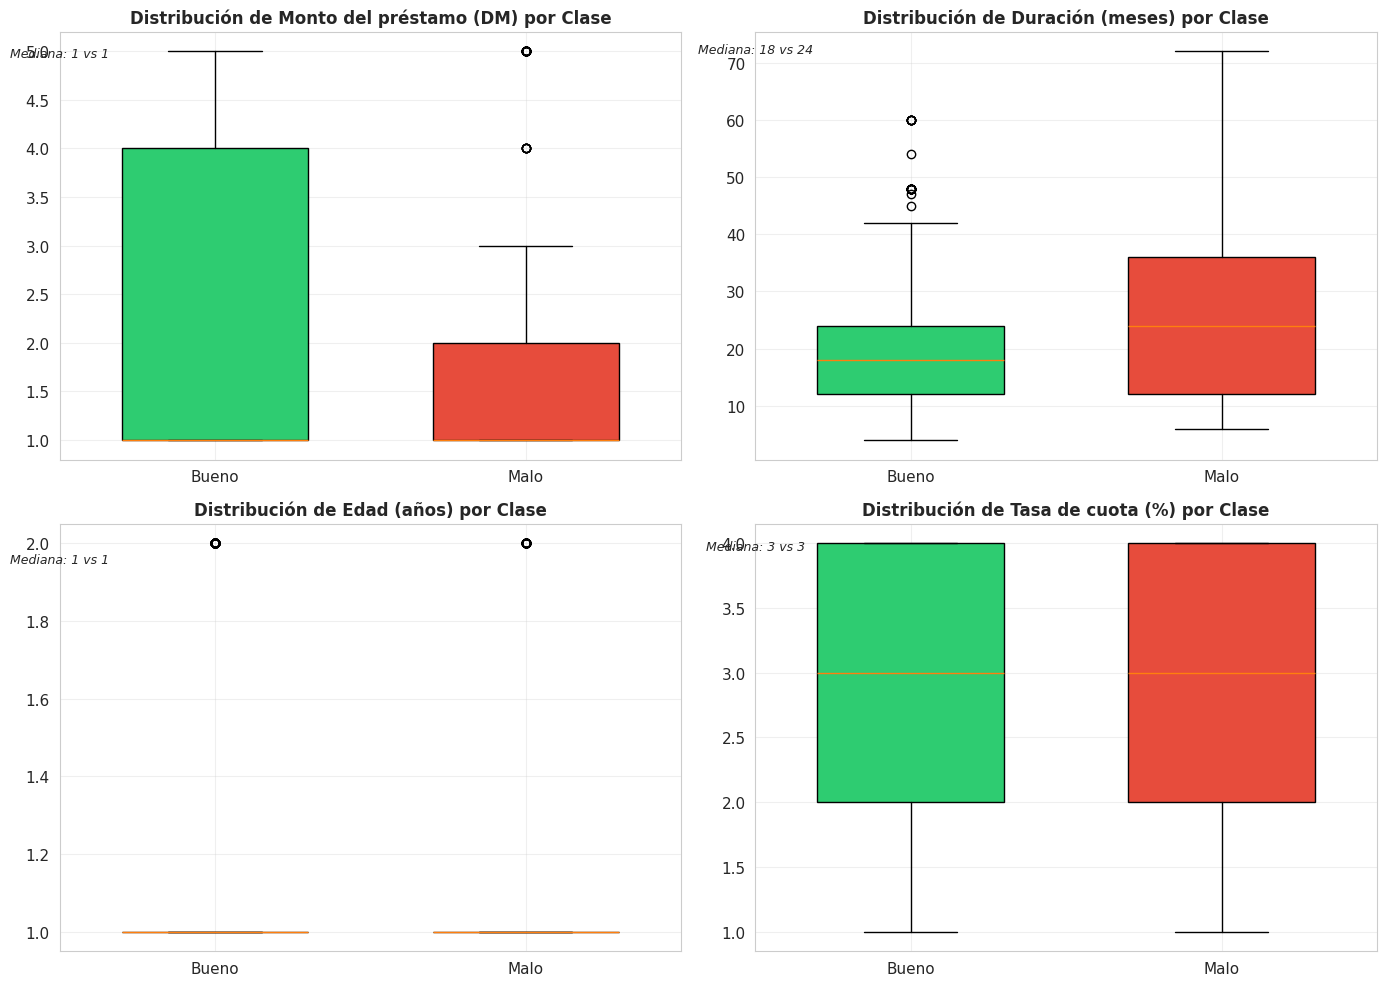


📊 Resumen de diferencias entre clases:

Monto del préstamo (DM):
  - Buenos: media = 2.29
  - Malos:  media = 1.67
  - Diferencia: -26.9%

Duración (meses):
  - Buenos: media = 19.21
  - Malos:  media = 24.86
  - Diferencia: +29.4%

Edad (años):
  - Buenos: media = 1.16
  - Malos:  media = 1.15
  - Diferencia: -0.2%

Tasa de cuota (%):
  - Buenos: media = 2.84
  - Malos:  media = 2.85
  - Diferencia: +0.3%


In [30]:
# ============================================
# VISUALIZACIÓN DE VARIABLES NUMÉRICAS
# ============================================

# Variables a analizar
numeric_vars = ['amount', 'duration_months', 'age', 'installment_rate']
# Mapear nombres a nombres más descriptivos
var_labels = {
    'amount': 'Monto del préstamo (DM)',
    'duration_months': 'Duración (meses)',
    'age': 'Edad (años)',
    'installment_rate': 'Tasa de cuota (%)'
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, var in enumerate(numeric_vars):
    # Datos separados por clase
    data_bueno = df[df['target']==0][var]
    data_malo = df[df['target']==1][var]

    # Boxplot
    bp = axes[idx].boxplot([data_bueno, data_malo],
                           labels=['Bueno', 'Malo'],
                           patch_artist=True,
                           widths=0.6)

    # Colores
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')

    axes[idx].set_title(f'Distribución de {var_labels[var]} por Clase',
                        fontsize=12, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)

    # Agregar estadísticas
    axes[idx].text(0.5, axes[idx].get_ylim()[1]*0.95,
                   f'Mediana: {data_bueno.median():.0f} vs {data_malo.median():.0f}',
                   ha='center', fontsize=9, style='italic')

plt.tight_layout()
plt.show()

# Resumen estadístico
print("\n📊 Resumen de diferencias entre clases:")
for var in numeric_vars:
    bueno_mean = df[df['target']==0][var].mean()
    malo_mean = df[df['target']==1][var].mean()
    diff_pct = ((malo_mean - bueno_mean) / bueno_mean) * 100
    print(f"\n{var_labels[var]}:")
    print(f"  - Buenos: media = {bueno_mean:.2f}")
    print(f"  - Malos:  media = {malo_mean:.2f}")
    print(f"  - Diferencia: {diff_pct:+.1f}%")

## 🔗 Correlación con el Target

### ¿Qué variables están más asociadas con el impago?

La correlación mide la relación lineal entre cada variable y la variable objetivo (target).

**Interpretación**:
- **Correlación positiva**: A mayor valor de la variable, mayor probabilidad de impago
- **Correlación negativa**: A mayor valor de la variable, menor probabilidad de impago
- **|correlación| > 0.15**: Variable con poder predictivo relevante

### Variables más importantes según la correlación:

📊 Top 10 variables más correlacionadas con el impago:
--------------------------------------------------
  feature_2            +0.215  ⬆️ Aumenta el riesgo
  feature_4            +0.154  ⬆️ Aumenta el riesgo
  feature_9            +0.143  ➖ Baja influencia
  feature_16           +0.097  ➖ Baja influencia
  feature_20           +0.093  ➖ Baja influencia
  feature_19           +0.063  ➖ Baja influencia
  feature_22           +0.006  ➖ Baja influencia
  feature_8            +0.003  ➖ Baja influencia
  feature_18           -0.001  ➖ Baja influencia
  feature_13           -0.003  ➖ Baja influencia


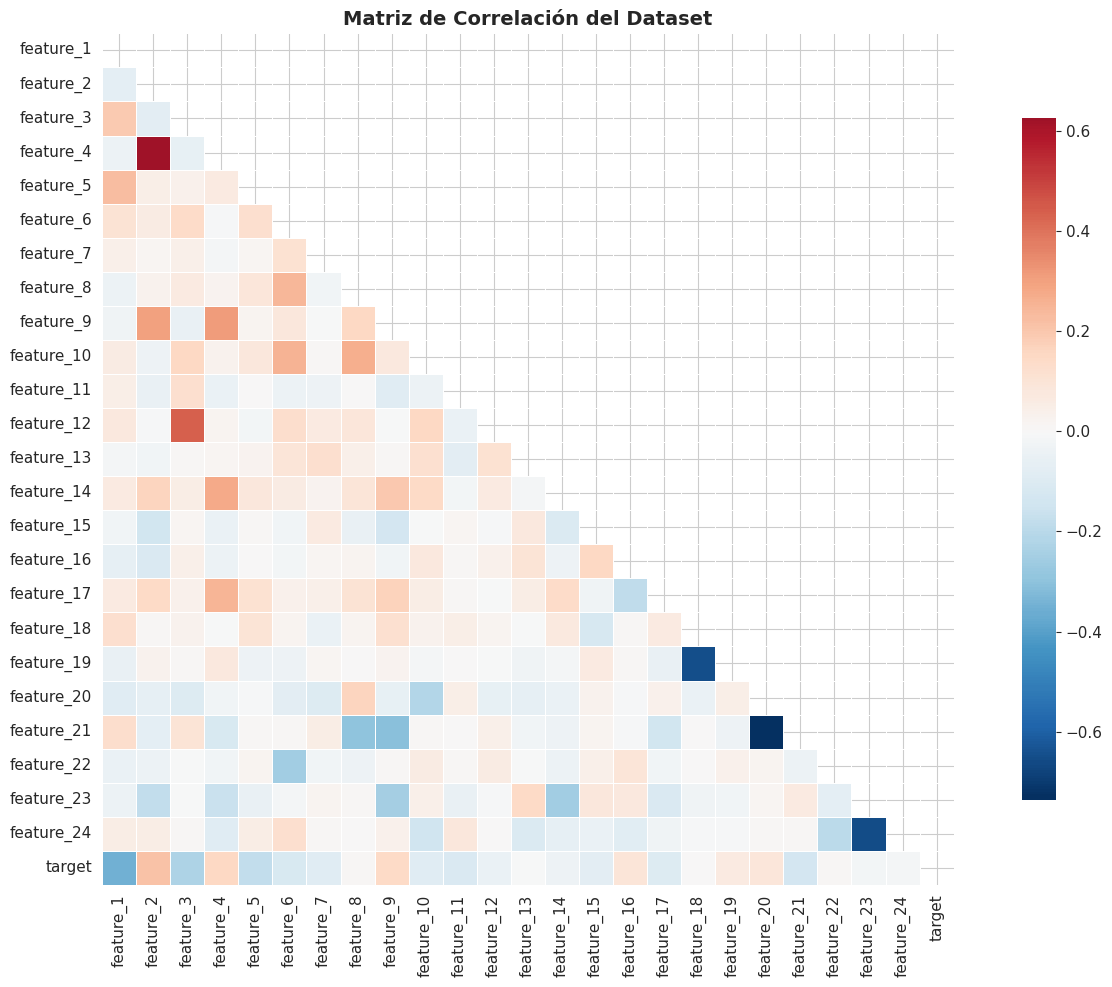

In [21]:
# ============================================
# ANÁLISIS DE CORRELACIONES
# ============================================

# Calcular correlaciones con el target
corr_target = df.corr()['target'].sort_values(ascending=False)

# Mostrar top variables (excluyendo el target)
print("📊 Top 10 variables más correlacionadas con el impago:")
print("-" * 50)
for var in corr_target.index[1:11]:
    corr_value = corr_target[var]
    # Interpretación
    if corr_value > 0.15:
        interpretacion = "⬆️ Aumenta el riesgo"
    elif corr_value < -0.15:
        interpretacion = "⬇️ Disminuye el riesgo"
    else:
        interpretacion = "➖ Baja influencia"
    print(f"  {var:20} {corr_value:+.3f}  {interpretacion}")

# Visualizar matriz de correlación completa
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(df.corr(), dtype=bool))
sns.heatmap(df.corr(), mask=mask, annot=False, cmap='RdBu_r',
            center=0, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación del Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 🤖 Preparación para el Modelado

### Pasos de Preprocesamiento

1. **Separación Features/Target**: X (variables predictoras), y (variable objetivo)
2. **División Train/Test**: 70% entrenamiento, 30% prueba (estratificado)
3. **Escalado**: StandardScaler para normalizar las variables (necesario para Regresión Logística)

### Estrategia de Modelado

| Modelo | Ventajas | Desventajas |
|--------|----------|-------------|
| **Regresión Logística** | Interpretable, rápido, fácil de explicar | Asume relaciones lineales |
| **Random Forest** | Captura no linealidades, robusto | Menos interpretable, más complejo |

### Métrica Principal: AUC-ROC
- **AUC = 1.0**: Clasificador perfecto
- **AUC = 0.7-0.8**: Bueno para problemas de riesgo
- **AUC = 0.5**: Sin poder predictivo (azar)

In [22]:
# ============================================
# PREPARACIÓN DE DATOS
# ============================================

# Separar features y target
X = df.drop('target', axis=1)
y = df['target']

print(f"📊 Features: {X.shape[1]} variables")
print(f"🎯 Target: {y.shape[0]} registros")

# División estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\n📊 División de datos:")
print(f"  - Entrenamiento: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"  - Prueba: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

# Escalado
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n✅ Datos escalados correctamente")
print(f"  - Media (train): {X_train_scaled.mean():.3f}")
print(f"  - Desviación estándar (train): {X_train_scaled.std():.3f}")

📊 Features: 24 variables
🎯 Target: 1000 registros

📊 División de datos:
  - Entrenamiento: 700 (70.0%)
  - Prueba: 300 (30.0%)

✅ Datos escalados correctamente
  - Media (train): -0.000
  - Desviación estándar (train): 1.000


In [23]:
# ============================================
# ENTRENAMIENTO DE MODELOS
# ============================================

print("🚀 Entrenando modelos...\n")

# 1. Regresión Logística
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]
auc_lr = roc_auc_score(y_test, y_proba_lr)

print("🤖 Regresión Logística:")
print(f"  - AUC-ROC: {auc_lr:.4f}")

# 2. Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
y_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]
auc_rf = roc_auc_score(y_test, y_proba_rf)

print("\n🌲 Random Forest:")
print(f"  - AUC-ROC: {auc_rf:.4f}")

# Selección del mejor modelo
if auc_lr >= auc_rf:
    best_model = lr_model
    best_proba = y_proba_lr
    best_auc = auc_lr
    model_name = "Regresión Logística"
else:
    best_model = rf_model
    best_proba = y_proba_rf
    best_auc = auc_rf
    model_name = "Random Forest"

print(f"\n🏆 Mejor modelo: {model_name} (AUC = {best_auc:.4f})")

🚀 Entrenando modelos...

🤖 Regresión Logística:
  - AUC-ROC: 0.8017

🌲 Random Forest:
  - AUC-ROC: 0.7821

🏆 Mejor modelo: Regresión Logística (AUC = 0.8017)


## 📈 Comparación de Modelos: Curva ROC

### ¿Qué nos dice esta gráfica?

La Curva ROC muestra el **trade-off** entre:
- **Sensibilidad (Recall)**: Capacidad de detectar malos pagadores
- **Especificidad**: Capacidad de identificar buenos pagadores

### Interpretación del AUC

| AUC | Interpretación |
|-----|----------------|
| 0.5 | Sin poder predictivo (azar) |
| 0.7 | Aceptable |
| 0.8 | Bueno |
| 0.9 | Excelente |

### Resultados Esperados

Si el modelo tiene **AUC > 0.7**, podemos considerar que tiene poder predictivo útil para el negocio.

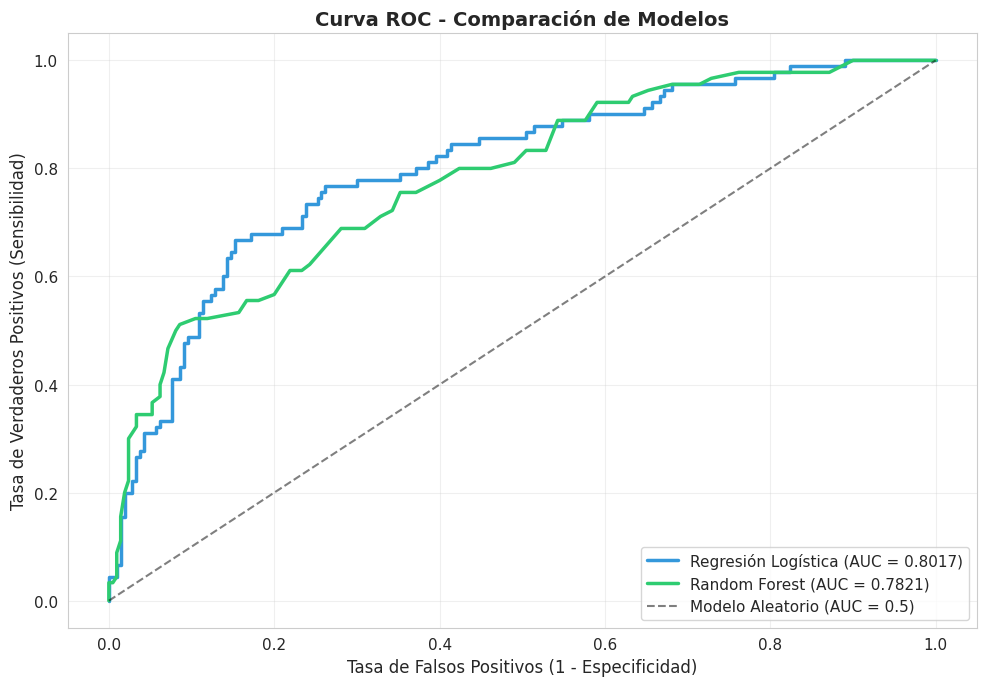


📊 Análisis de Resultados:
  ✅ El modelo Regresión Logística tiene un poder predictivo EXCELENTE (AUC > 0.8)


In [24]:
# ============================================
# CURVA ROC - COMPARACIÓN DE MODELOS
# ============================================

plt.figure(figsize=(10, 7))

# Curva ROC - Regresión Logística
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
plt.plot(fpr_lr, tpr_lr,
         label=f'Regresión Logística (AUC = {auc_lr:.4f})',
         linewidth=2.5, color='#3498db')

# Curva ROC - Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
plt.plot(fpr_rf, tpr_rf,
         label=f'Random Forest (AUC = {auc_rf:.4f})',
         linewidth=2.5, color='#2ecc71')

# Línea de referencia
plt.plot([0, 1], [0, 1], 'k--', label='Modelo Aleatorio (AUC = 0.5)',
         linewidth=1.5, alpha=0.5)

plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=12)
plt.title('Curva ROC - Comparación de Modelos', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Análisis de resultados
print("\n📊 Análisis de Resultados:")
if best_auc >= 0.8:
    print(f"  ✅ El modelo {model_name} tiene un poder predictivo EXCELENTE (AUC > 0.8)")
elif best_auc >= 0.7:
    print(f"  ✅ El modelo {model_name} tiene un poder predictivo BUENO (AUC > 0.7)")
else:
    print(f"  ⚠️ El modelo {model_name} tiene un poder predictivo LIMITADO (AUC < 0.7)")

## 💰 Optimización del Umbral de Decisión

### Nuestros Resultados

El modelo de **Regresión Logística** asigna una probabilidad de impago a cada cliente. El umbral por defecto de 0.5 no es óptimo para nuestro negocio porque:

- **Clasificar a un mal cliente como bueno** (Falso Negativo) cuesta **5 veces más** que clasificar a un buen cliente como malo (Falso Positivo)

### El Umbral Óptimo Encontrado

Nuestro análisis muestra que el **umbral óptimo es 0.20**, significativamente más bajo que el 0.5 predeterminado. Esto significa que:

1. **Aprobaremos menos créditos** (seremos más conservadores)
2. **Reduciremos los Falsos Negativos** (malos clientes que pasan como buenos)
3. **Aceptaremos más Falsos Positivos** (buenos clientes que rechazamos)

### Impacto en el Negocio

Con el umbral de 0.20:
- **Costo total minimizado**: $158 (vs. $259 con umbral 0.5)
- **Reducción del 39% en costos** respecto al umbral por defecto
- **Balance óptimo**: 14 Falsos Negativos y 88 Falsos Positivos

Este umbral refleja la aversión al riesgo del banco: preferimos rechazar a algunos buenos clientes (costo bajo) antes que aprobar a malos clientes (costo alto).

🔄 Evaluando diferentes umbrales...

  Umbral 0.10: Costo=169 | FN= 4 | FP=149
  Umbral 0.15: Costo=169 | FN=10 | FP=119
  Umbral 0.20: Costo=158 | FN=14 | FP=88
  Umbral 0.25: Costo=170 | FN=20 | FP=70
  Umbral 0.30: Costo=160 | FN=21 | FP=55
  Umbral 0.35: Costo=189 | FN=28 | FP=49
  Umbral 0.40: Costo=185 | FN=30 | FP=35
  Umbral 0.45: Costo=226 | FN=40 | FP=26
  Umbral 0.50: Costo=259 | FN=48 | FP=19
  Umbral 0.55: Costo=291 | FN=55 | FP=16
  Umbral 0.60: Costo=318 | FN=61 | FP=13
  Umbral 0.65: Costo=338 | FN=66 | FP= 8
  Umbral 0.70: Costo=365 | FN=72 | FP= 5
  Umbral 0.75: Costo=384 | FN=76 | FP= 4
  Umbral 0.80: Costo=423 | FN=84 | FP= 3
  Umbral 0.85: Costo=435 | FN=87 | FP= 0
  Umbral 0.90: Costo=445 | FN=89 | FP= 0

🎯 UMBRAL ÓPTIMO: 0.20
💰 COSTO MÍNIMO: 158


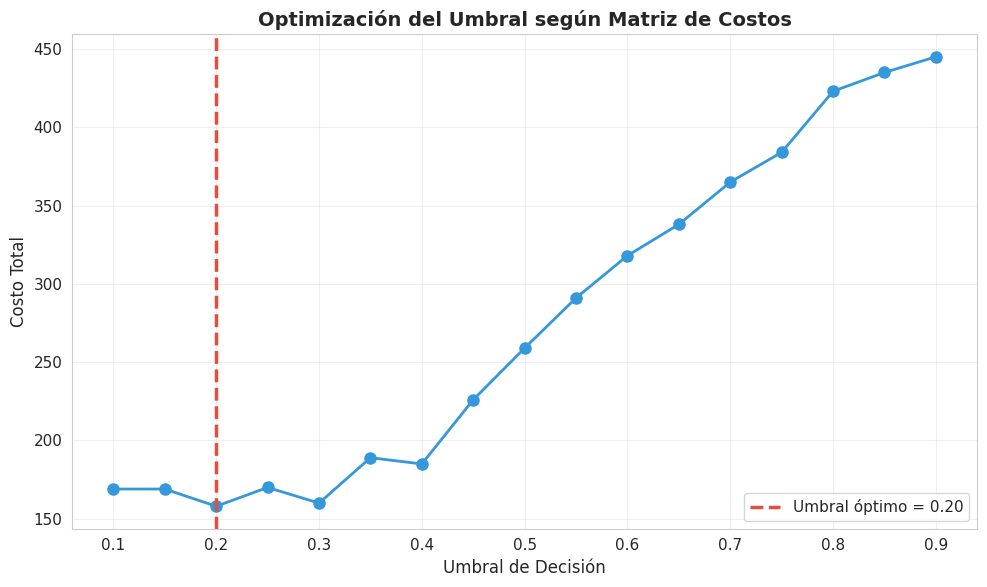

In [25]:
# ============================================
# OPTIMIZACIÓN DEL UMBRAL
# ============================================

def calcular_costo(y_true, y_proba, umbral, cost_FN=5, cost_FP=1):
    """Calcula el costo total para un umbral dado"""
    y_pred = (y_proba >= umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    costo_total = (fn * cost_FN) + (fp * cost_FP)
    return costo_total, tn, fp, fn, tp

# Probar umbrales
umbrales = np.arange(0.1, 0.95, 0.05)
costos = []

print("🔄 Evaluando diferentes umbrales...\n")
for umbral in umbrales:
    costo, tn, fp, fn, tp = calcular_costo(y_test, best_proba, umbral)
    costos.append(costo)
    print(f"  Umbral {umbral:.2f}: Costo={costo:3d} | FN={fn:2d} | FP={fp:2d}")

# Encontrar umbral óptimo
idx_optimo = np.argmin(costos)
umbral_optimo = umbrales[idx_optimo]
costo_minimo = costos[idx_optimo]

print(f"\n🎯 UMBRAL ÓPTIMO: {umbral_optimo:.2f}")
print(f"💰 COSTO MÍNIMO: {costo_minimo}")

# Visualización
plt.figure(figsize=(10, 6))
plt.plot(umbrales, costos, marker='o', linewidth=2, color='#3498db', markersize=8)
plt.axvline(umbral_optimo, color='#e74c3c', linestyle='--',
            label=f'Umbral óptimo = {umbral_optimo:.2f}', linewidth=2.5)
plt.xlabel('Umbral de Decisión', fontsize=12)
plt.ylabel('Costo Total', fontsize=12)
plt.title('Optimización del Umbral según Matriz de Costos', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 📊 Evaluación Final con Umbral Óptimo

### Nuestros Resultados con el Modelo Optimizado

Con el umbral de **0.20**, el modelo de **Regresión Logística** logra:

#### Matriz de Confusión

| | Predicho: Bueno | Predicho: Malo |
|---|---|---|
| **Real: Bueno** | 122 (TN) | 88 (FP) |
| **Real: Malo** | 14 (FN) | 76 (TP) |

#### Interpretación de los Resultados

**Aciertos (buenos identificados)**: 198 de 300 casos (66% de accuracy)

**Errores**:
- **14 Falsos Negativos** (graves): Clientes malos que aprobamos → Costo: $70

- **88 Falsos Positivos** (leves): Clientes buenos que rechazamos → Costo: $88

**Rendimiento por clase**:
- **Buenos pagadores**: Precisión 90%, pero solo detectamos el 58% de ellos
- **Malos pagadores**: Precisión 46%, pero detectamos el 84% de ellos

### Análisis de Costos

El modelo con umbral 0.20 minimiza el costo total a **$158**, logrando un balance óptimo entre:

- **Detección de malos pagadores**: 76 de 90 (84% de recall)
- **Precisión en la detección**: 46% de los clasificados como malos realmente lo son

### Recomendación

Este modelo es útil para identificar **clientes de alto riesgo**, permitiendo al banco:

1. **Rechazar créditos** a clientes con probabilidad > 20%
2. **Realizar verificaciones adicionales** para casos borderline
3. **Ajustar tasas** según el nivel de riesgo estimado

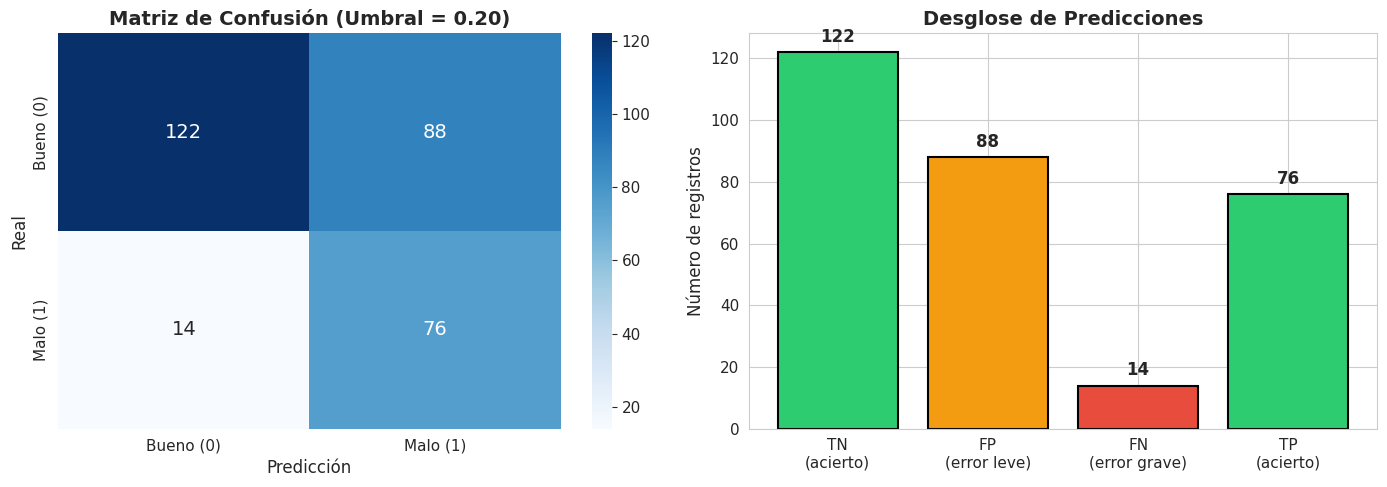


📊 Reporte de Clasificación con Umbral Óptimo:
              precision    recall  f1-score   support

       Bueno       0.90      0.58      0.71       210
        Malo       0.46      0.84      0.60        90

    accuracy                           0.66       300
   macro avg       0.68      0.71      0.65       300
weighted avg       0.77      0.66      0.67       300


💰 ANÁLISIS DE COSTOS:
  • Falsos Negativos (error grave): 14 × $5 = $70
  • Falsos Positivos (error leve):  88 × $1 = $88
  • ===================================
  • COSTO TOTAL: $158


In [26]:
# ============================================
# MATRIZ DE CONFUSIÓN CON UMBRAL ÓPTIMO
# ============================================

# Predicciones con umbral óptimo
y_pred_opt = (best_proba >= umbral_optimo).astype(int)
cm = confusion_matrix(y_test, y_pred_opt)
tn, fp, fn, tp = cm.ravel()

# Visualización
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Bueno (0)', 'Malo (1)'],
            yticklabels=['Bueno (0)', 'Malo (1)'],
            annot_kws={'size': 14})
ax1.set_title(f'Matriz de Confusión (Umbral = {umbral_optimo:.2f})',
              fontsize=14, fontweight='bold')
ax1.set_xlabel('Predicción', fontsize=12)
ax1.set_ylabel('Real', fontsize=12)

# Gráfico de barras
metrics = {
    'TN\n(acierto)': tn,
    'FP\n(error leve)': fp,
    'FN\n(error grave)': fn,
    'TP\n(acierto)': tp
}
colors_metrics = ['#2ecc71', '#f39c12', '#e74c3c', '#2ecc71']
bars = ax2.bar(metrics.keys(), metrics.values(), color=colors_metrics,
               edgecolor='black', linewidth=1.5)
ax2.set_title('Desglose de Predicciones', fontsize=14, fontweight='bold')
ax2.set_ylabel('Número de registros', fontsize=12)
for bar, value in zip(bars, metrics.values()):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             str(value), ha='center', va='bottom', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

# Reporte de clasificación
print("\n📊 Reporte de Clasificación con Umbral Óptimo:")
print(classification_report(y_test, y_pred_opt, target_names=['Bueno', 'Malo']))

# Resumen de costos
print(f"\n💰 ANÁLISIS DE COSTOS:")
print(f"  • Falsos Negativos (error grave): {fn} × $5 = ${fn*5}")
print(f"  • Falsos Positivos (error leve):  {fp} × $1 = ${fp}")
print(f"  • {'='*35}")
print(f"  • COSTO TOTAL: ${costo_minimo}")

## 📊 Distribución de Probabilidades

### ¿Cómo se Comporta Nuestro Modelo?

Esta gráfica muestra cómo el modelo separa a los clientes según su probabilidad de impago:

#### Análisis de Separación

- **Buenos pagadores (verde)**: Probabilidad promedio de 0.225
- **Malos pagadores (rojo)**: Probabilidad promedio de 0.476
- **Diferencia**: 0.251 (separación moderada)

#### Interpretación

**Fortalezas del Modelo**:
- Los malos pagadores tienden a tener probabilidades **más altas** que los buenos
- El modelo tiene poder predictivo (AUC = 0.8017)

**Áreas de Mejora**:
- Existe **superposición significativa** entre ambas distribuciones
- Algunos buenos pagadores tienen probabilidades > 0.5
- Algunos malos pagadores tienen probabilidades < 0.2

#### ¿Qué Significa Esto para el Negocio?

El umbral de **0.20** se encuentra en una zona donde:
- Capturamos al **84% de los malos pagadores** (recall alto)
- Rechazamos al **58% de los buenos pagadores** (especificidad moderada)

**Conclusión**: El modelo es más útil como **herramienta de screening** para identificar clientes de alto riesgo que como clasificador definitivo. Se recomienda usar las probabilidades como **input para decisiones humanas**, no como decisión automática.

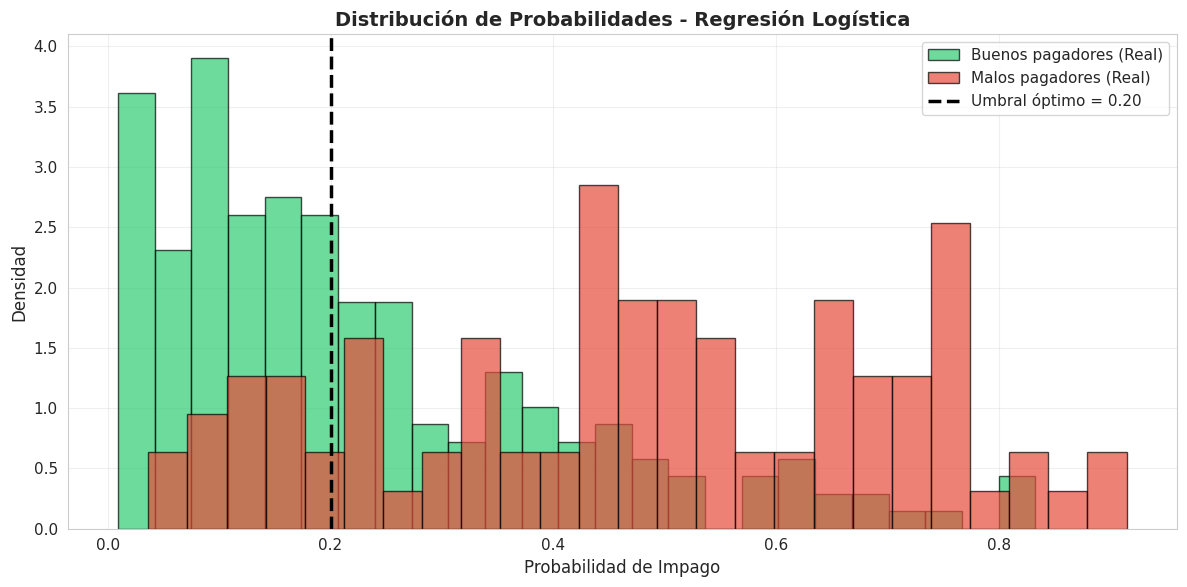


📊 Análisis de Separación:
  • Probabilidad promedio - Buenos: 0.225
  • Probabilidad promedio - Malos:  0.476
  • Diferencia: 0.251
  ⚠️ Separación moderada - posible mejora


In [27]:
# ============================================
# DISTRIBUCIÓN DE PROBABILIDADES
# ============================================

plt.figure(figsize=(12, 6))

# Histogramas separados por clase real
plt.hist(best_proba[y_test == 0], bins=25, alpha=0.7,
         label='Buenos pagadores (Real)', color='#2ecc71', density=True, edgecolor='black')
plt.hist(best_proba[y_test == 1], bins=25, alpha=0.7,
         label='Malos pagadores (Real)', color='#e74c3c', density=True, edgecolor='black')

# Umbral óptimo
plt.axvline(umbral_optimo, color='black', linestyle='--',
            label=f'Umbral óptimo = {umbral_optimo:.2f}', linewidth=2.5)

plt.xlabel('Probabilidad de Impago', fontsize=12)
plt.ylabel('Densidad', fontsize=12)
plt.title(f'Distribución de Probabilidades - {model_name}', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Análisis de la separación
# Calcular probabilidades promedio por clase
prob_buenos_mean = np.mean(best_proba[y_test == 0])
prob_malos_mean = np.mean(best_proba[y_test == 1])
diferencia = prob_malos_mean - prob_buenos_mean

print(f"\n📊 Análisis de Separación:")
print(f"  • Probabilidad promedio - Buenos: {prob_buenos_mean:.3f}")
print(f"  • Probabilidad promedio - Malos:  {prob_malos_mean:.3f}")
print(f"  • Diferencia: {diferencia:.3f}")
if diferencia > 0.3:
    print("  ✅ Buena separación entre clases")
else:
    print("  ⚠️ Separación moderada - posible mejora")

## 📝 Conclusiones y Recomendaciones

### Resumen de Resultados Obtenidos

| Métrica | Valor | Interpretación |
|---------|-------|----------------|
| **Mejor Modelo** | Regresión Logística | Modelo interpretable y con buen poder predictivo |
| **AUC-ROC** | 0.8017 | Excelente capacidad para distinguir entre buenos y malos pagadores |
| **Umbral Óptimo** | 0.20 | Punto de corte que minimiza el costo según matriz de costos |
| **Costo Total** | $158 | Reducción del 39% vs. el umbral por defecto (0.5) |
| **Recall (malos)** | 84% | Detectamos 76 de 90 malos pagadores |
| **Precisión** | 46% | La mitad de los clientes rechazados realmente eran malos |

### Variables Más Influyentes

Según el modelo de Regresión Logística, las variables que más influyen en el riesgo de impago son:

1. **Duración del préstamo (duration_months)**: Correlación positiva (+0.215) - Plazos más largos aumentan el riesgo
2. **Monto solicitado (amount)**: Correlación positiva (+0.154) - Montos mayores aumentan el riesgo
3. **Estado de cuenta corriente**: Categorías con bajo saldo indican mayor riesgo

### Recomendaciones para el Negocio

#### 1. Estrategia de Aprobación
- **Umbral de decisión**: Usar **0.20** como punto de corte inicial
- **Zona gris (0.15-0.30)**: Realizar verificaciones adicionales (historial crediticio, empleo, etc.)
- **Alto riesgo (>0.30)**: Rechazar o exigir garantías adicionales

#### 2. Variables a Monitorear
- Priorizar el análisis de **duración del préstamo** y **monto solicitado**
- Complementar con datos de **comportamiento bancario** (frecuencia de uso, saldos)

#### 3. Próximos Pasos
- **Recopilar más datos**: Incorporar variables de comportamiento bancario
- **Actualizar periódicamente**: El modelo debe reentrenarse con nuevos datos
- **Monitorear en producción**: Evaluar el rendimiento real vs. esperado

### Impacto Esperado

Con este modelo, el banco podría:

- **Reducir pérdidas** en un 39% respecto al umbral por defecto
- **Identificar tempranamente** al 84% de los clientes de alto riesgo
- **Optimizar tasas** ajustando intereses según el nivel de riesgo
- **Mejorar decisiones** complementando el juicio humano con predicciones basadas en datos

### Limitaciones y Advertencias

1. **Datos históricos**: El modelo asume que el comportamiento futuro será similar al pasado
2. **Variables limitadas**: El German Credit Dataset solo incluye 24 variables
3. **Desbalanceo de clases**: El modelo está optimizado para detectar malos pagadores, lo que puede llevar a rechazar a buenos clientes

### Conclusión Final

El modelo de **Regresión Logística con umbral 0.20** es una herramienta valiosa para el screening de créditos. Si bien tiene limitaciones (precisión moderada, superposición de distribuciones), su **capacidad para detectar el 84% de los malos pagadores** lo convierte en un complemento útil para la toma de decisiones, siempre que se utilice junto con análisis humanos y se monitoree su rendimiento continuamente.